### Le modele de GVAR 

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dataclasses import dataclass


In [22]:
# ====== PARAMETRES DU MODELE ======
P = 0       # lags sur Z_i (domestique) : 1..P
P_star = 1  # lags sur Z_i* (étranger) : 0..P_star
L = 1       # lags sur X (macro) : 0..L

Z_FOLDER = "data/facteurs_systemiq/zt_am/zt_by_sector.csv"
MACRO_PATH = "data/macro_data/df_macro_stationary.csv"

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

W = "data/international_TES/W_USA.csv"


In [23]:
def load_Z_single_csv(path_csv: str) -> pd.DataFrame:
    """
    Charge un seul CSV contenant :
    sector, year_quarter, z_t
    et le transforme en matrice (date × secteur)
    """
    df = pd.read_csv(path_csv)

    df["year_quarter"] = pd.to_datetime(df["year_quarter"])

    # Pivot : lignes = date, colonnes = secteur
    Z = df.pivot(
        index="year_quarter",
        columns="sector",
        values="z_t"
    )

    Z = Z.sort_index()

    return Z


In [24]:
Z = load_Z_single_csv(Z_FOLDER)
Z.head(10)


sector,construction_immo,extraction_primaire,finance,industrie,info-com,public,services,services_pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439
2011-10-01,-1.656445,0.949014,-1.228758,-0.130107,-0.198410,0.643175,-0.834454,-2.045196
2012-01-01,1.672773,0.778933,-0.611153,-0.170126,-0.358526,0.083938,-0.810922,-1.409588
2012-04-01,-1.552605,-0.154775,0.600996,-0.041919,0.890062,-0.131946,0.371942,-0.410847
2012-07-01,-1.456050,-0.166745,0.900720,-0.216857,-0.450470,1.693689,0.398834,-0.410847


In [25]:
W_PATH = "data/international_TES/W_USA.csv"

W = pd.read_csv(W_PATH, index_col=0)
print(W.shape)
print(W.index[:5])
print(W.columns[:5])


(8, 8)
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='object')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='object')


In [26]:
print(Z.columns)
print(W.index)


Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='object', name='sector')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object')


In [27]:
W.iloc[:8, :8]


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [28]:
# Charger le fichier Excel
df_macro_raw= pd.read_excel("data\macro_data\Données_macro_hist_v3.xlsx")

# Preprocessing du dataframe
df = df_macro_raw.copy()

id_cols = ["Region", "Variable", "Unit"]
value_cols = [c for c in df.columns if c not in id_cols]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="quarter",
    value_name="value"
)

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\id2415\AppData\Local\Temp\ipykernel_8736\2714791701.py:2: SyntaxWarning: invalid escape sequence '\m'
  df_macro_raw= pd.read_excel("data\macro_data\Données_macro_hist_v3.xlsx")


In [29]:
# Sélection des régions
regions_keep = ["United States"]
df = df_macro_raw[df_macro_raw["Region"].isin(regions_keep)].copy()
# Colonnes temporelles
time_cols = [c for c in df.columns if "-" in c]
# On garde uniquement les lignes sans NaN sur toute la période
df = df.dropna(subset=time_cols)
# Mapping régions → suffixes
region_map = {
    "United States": "US"
}

def clean_var_name(var):
    return (
        var.strip()
           .replace(" ", "_")
           .replace("(", "")
           .replace(")", "")
           .replace("/", "_")
    )

df["var_name"] = (
    df["Region"].map(region_map)
    + "_"
    + df["Variable"].apply(clean_var_name)
)


# Passage au format long
df_long = df.melt(
    id_vars=["var_name"],
    value_vars=time_cols,
    var_name="date",
    value_name="value"
)

# Pivot final
X = df_long.pivot(
    index="date",
    columns="var_name",
    values="value"
).sort_index()

# Conversion "2010-Q1" → PeriodIndex trimestriel
X.index = pd.PeriodIndex(X.index, freq="Q").to_timestamp()

In [30]:
X.head()

var_name,US_Central_bank_Intervention_rate_policy_interest_rate,US_Effective_exchange_rate,US_Equity_prices,US_GDP_Growth_Rate,US_House_prices_residential,US_Inflation_rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate
date,,,,,,,,,
2010-01-01,0.125,84.740000,46.875171,0.484501,94.481014,2.360525,3.716667,76.674837,9.833333
2010-04-01,0.125,86.106667,41.314746,0.967586,93.876843,1.767765,3.490000,78.845036,9.633333
2010-07-01,0.125,84.923333,45.743602,0.771085,92.137491,1.175609,2.786667,76.675000,9.466666
2010-10-01,0.125,81.390000,50.410959,0.525110,90.641295,1.270248,2.863333,87.033160,9.500000
2011-01-01,0.125,80.343333,53.144269,-0.237205,87.908116,2.141127,3.460000,105.369424,9.033334


In [31]:
# Au lieu de chercher la colonne "date", on manipule directement l'index
X.index = pd.to_datetime(X.index)
X = X.sort_index()
X.head()

var_name,US_Central_bank_Intervention_rate_policy_interest_rate,US_Effective_exchange_rate,US_Equity_prices,US_GDP_Growth_Rate,US_House_prices_residential,US_Inflation_rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate
date,,,,,,,,,
2010-01-01,0.125,84.740000,46.875171,0.484501,94.481014,2.360525,3.716667,76.674837,9.833333
2010-04-01,0.125,86.106667,41.314746,0.967586,93.876843,1.767765,3.490000,78.845036,9.633333
2010-07-01,0.125,84.923333,45.743602,0.771085,92.137491,1.175609,2.786667,76.675000,9.466666
2010-10-01,0.125,81.390000,50.410959,0.525110,90.641295,1.270248,2.863333,87.033160,9.500000
2011-01-01,0.125,80.343333,53.144269,-0.237205,87.908116,2.141127,3.460000,105.369424,9.033334


In [12]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='object', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object')


In [32]:
rename_dict = {
    "construction_immo": "Construction & immobilier",
    "extraction_primaire": "Primaires & énergie",
    "finance": "Finance",
    "industrie": "Industrie",
    "info-com": "Info-com",
    "public": "Public & services non-marchands",
    "services": "Services",
    "services_pro": "Services pro"
}

Z = Z.rename(columns=rename_dict)


In [33]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['Construction & immobilier', 'Primaires & énergie', 'Finance',
       'Industrie', 'Info-com', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object')


In [34]:
# Secteurs : Z doit contenir tous les secteurs de W
missing = sorted(set(W.index) - set(Z.columns))
if missing:
    raise ValueError(f"Z ne contient pas tous les secteurs de W : {missing}")

# Garder uniquement les secteurs de W, dans le même ordre
Z = Z[W.index].copy()

# Alignement sur dates communes (et dropna)
df_base = pd.concat([Z, X], axis=1).dropna()

print("Z:", Z.shape, "| X:", X.shape, "| Base alignée:", df_base.shape)


Z: (51, 8) | X: (56, 9) | Base alignée: (51, 17)


In [35]:
df_base.head()

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,US_Central_bank_Intervention_rate_policy_interest_rate,US_Effective_exchange_rate,US_Equity_prices,US_GDP_Growth_Rate,US_House_prices_residential,US_Inflation_rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,0.125,84.923333,45.743602,0.771085,92.137491,1.175609,2.786667,76.675000,9.466666
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,0.125,81.390000,50.410959,0.525110,90.641295,1.270248,2.863333,87.033160,9.500000
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,0.125,80.343333,53.144269,-0.237205,87.908116,2.141127,3.460000,105.369424,9.033334
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,0.125,78.926667,52.936237,0.676582,86.310846,3.430395,3.210000,117.541905,9.066667
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,0.125,79.426667,45.351586,-0.022313,86.167368,3.756174,2.426667,113.266948,9.000000


In [37]:
def compute_Z_star(Z: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    W2 = W.copy()
    Z_star = Z @ W2.T
    Z_star.columns = [f"{c}_star" for c in Z_star.columns]
    return Z_star

Z_star = compute_Z_star(Z, W)

# Dataset complet (Z, Z_star, X)
df_all = pd.concat([Z, Z_star, X], axis=1).dropna()
df_all.head()


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,Construction & immobilier_star,Finance_star,...,Services pro_star,US_Central_bank_Intervention_rate_policy_interest_rate,US_Effective_exchange_rate,US_Equity_prices,US_GDP_Growth_Rate,US_House_prices_residential,US_Inflation_rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,-1.564711,-1.865200,...,-1.582271,0.125,84.923333,45.743602,0.771085,92.137491,1.175609,2.786667,76.675000,9.466666
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,-0.913652,-1.024763,...,-0.791531,0.125,81.390000,50.410959,0.525110,90.641295,1.270248,2.863333,87.033160,9.500000
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-1.051116,-0.290600,...,-0.425792,0.125,80.343333,53.144269,-0.237205,87.908116,2.141127,3.460000,105.369424,9.033334
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,-0.701743,0.040945,...,-0.151725,0.125,78.926667,52.936237,0.676582,86.310846,3.430395,3.210000,117.541905,9.066667
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.531434,0.162462,...,-0.059817,0.125,79.426667,45.351586,-0.022313,86.167368,3.756174,2.426667,113.266948,9.000000


In [38]:
def lag_series(s: pd.Series, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag d'une série."""
    out = []
    for l in range(0, max_lag + 1):
        out.append(s.shift(l).rename(f"{prefix}L{l}"))
    return pd.concat(out, axis=1)

def lag_dataframe(df: pd.DataFrame, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag de toutes les colonnes d'un DF."""
    out = []
    for l in range(0, max_lag + 1):
        tmp = df.shift(l).add_prefix(f"{prefix}L{l}_")
        out.append(tmp)
    return pd.concat(out, axis=1)


#Estimation OLS secteur par secteur 

In [40]:
def estimate_sector_varx(
    df_all: pd.DataFrame,
    sector: str,
    macro_cols: list[str],
    P: int,
    P_star: int,
    L: int
):
    """
    Estime: Z_i(t) ~ const + lags(Z_i, 1..P) + lags(Z_i*, 0..P_star) + lags(X, 0..L)
    """
    y = df_all[sector]

    # --- Retards domestiques (1..P)
    X_dom = []
    for p in range(1, P + 1):
        X_dom.append(df_all[sector].shift(p).rename(f"ZL{p}"))

    X_dom = pd.concat(X_dom, axis=1) if X_dom else None

    # --- Retards étrangers (0..P_star)
    star_col = f"{sector}_star"
    X_star = lag_series(df_all[star_col], P_star, prefix="Zstar")  # L0..LP_star

    # --- Retards macro (0..L)
    X_macro = lag_dataframe(df_all[macro_cols], L, prefix="X_") if macro_cols else None

    # --- Assemblage régressions
    X_parts = []
    if X_dom is not None:
        X_parts.append(X_dom)
    X_parts.append(X_star)
    if X_macro is not None:
        X_parts.append(X_macro)

    Xreg = pd.concat(X_parts, axis=1)
    data = pd.concat([y.rename("y"), Xreg], axis=1).dropna()

    y2 = data["y"]
    X2 = sm.add_constant(data.drop(columns=["y"]))
    model = sm.OLS(y2, X2).fit()

    return model

macro_cols = list(X.columns)

models = {}
residuals = {}
coefs = {}

for s in W.index:
    m = estimate_sector_varx(df_all, sector=s, macro_cols=macro_cols, P=P, P_star=P_star, L=L)
    models[s] = m
    residuals[s] = m.resid
    coefs[s] = m.params

# Exemple d'output
first_sector = W.index[0]
print(first_sector)
print(models[first_sector].summary())


Construction & immobilier
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     1.080
Date:                Fri, 20 Feb 2026   Prob (F-statistic):              0.417
Time:                        14:45:32   Log-Likelihood:                -56.581
No. Observations:                  50   AIC:                             155.2
Df Residuals:                      29   BIC:                             195.3
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [41]:
coef_df = pd.DataFrame(coefs).T  # index=secteurs, colonnes=params
coef_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))

resid_df = pd.DataFrame(residuals).dropna()
resid_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

print("Saved:")
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

coef_df.head()


Saved:
 - data/output\gvar_step1_coef_all.csv
 - data/output\gvar_step1_residuals.csv


,const,ZstarL0,ZstarL1,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate,X_L0_US_Effective_exchange_rate,X_L0_US_Equity_prices,X_L0_US_GDP_Growth_Rate,X_L0_US_House_prices_residential,X_L0_US_Inflation_rate,X_L0_US_Long_term_interest_rate,...,X_L0_US_Unemployment_rate,X_L1_US_Central_bank_Intervention_rate_policy_interest_rate,X_L1_US_Effective_exchange_rate,X_L1_US_Equity_prices,X_L1_US_GDP_Growth_Rate,X_L1_US_House_prices_residential,X_L1_US_Inflation_rate,X_L1_US_Long_term_interest_rate,X_L1_US_Oil_price,X_L1_US_Unemployment_rate
Construction & immobilier,-1.634401,-0.418786,0.466567,-0.863210,-0.040446,0.023194,0.012176,-0.013994,0.512673,0.499599,...,0.194652,0.657733,0.099963,0.020229,0.052261,-0.092695,-0.026669,0.656588,0.013466,0.170478
Finance,11.614532,0.648238,0.169937,2.196593,0.005354,0.004929,-0.076189,-0.024582,-0.169540,0.427655,...,0.216194,-1.650595,-0.052180,0.059256,-0.020005,-0.092943,-0.021109,-1.145893,0.012330,-0.030366
Industrie,-3.251662,0.866543,0.324345,-1.090398,-0.002508,0.008406,-0.057178,-0.198258,-0.046634,0.672695,...,-0.032380,0.563748,0.030221,-0.009143,-0.004230,0.206848,0.036634,-0.314100,0.003676,0.111300
Info-com,5.070416,-0.009650,0.591865,0.986693,-0.047682,-0.004179,0.362046,-0.190479,-0.043376,0.157729,...,0.751001,-0.968540,0.048659,0.060933,0.073143,0.084791,-0.105863,-0.404091,0.027866,-0.416413
Primaires & énergie,9.969597,0.810540,0.562820,0.210929,-0.018003,-0.013714,0.192660,-0.379683,0.509337,-0.627363,...,0.283745,0.676223,-0.035984,0.004010,0.162814,0.367582,0.023386,-0.343602,-0.021228,-0.107841


# Construction du GVAR 

In [42]:
def build_B_matrices(W: pd.DataFrame, coef_df: pd.DataFrame, P_star: int):
    """
    Construit B_p pour p=0..P_star à partir des coefficients beta_i,p = coef['ZstarLp'].
    """
    N = W.shape[0]
    sectors = list(W.index)

    # sécurité : diagonale W nulle
    W2 = W.copy()
    np.fill_diagonal(W2.values, 0.0)

    B = {}
    for p in range(0, P_star + 1):
        # vecteur beta_{i,p} pour tous i
        beta_name = f"ZstarL{p}"
        if beta_name not in coef_df.columns:
            raise ValueError(f"Colonne manquante dans coef_df: {beta_name}")

        beta_vec = coef_df.loc[sectors, beta_name].values.reshape(-1, 1)  # (N,1)

        # B_p = diag(beta_vec) * W
        Bp = (beta_vec * W2.values)  # broadcasting ligne i
        np.fill_diagonal(Bp, 0.0)    # imposer (i,i)=0
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices(W, coef_df, P_star=P_star)

# Vérifier dimensions
print("B0 shape:", B[0].shape)

# Matrice G = I - B0 (utile si tu as un contemporain)
I = np.eye(W.shape[0])
G = pd.DataFrame(I - B[0].values, index=W.index, columns=W.columns)

# Vérifier inversibilité numérique (conditionnement)
cond_G = np.linalg.cond(G.values)
det_G = np.linalg.det(G.values)

print("det(G) =", det_G)
print("cond(G) =", cond_G)


B0 shape: (8, 8)
det(G) = 0.7390816524701281
cond(G) = 4.0648011653389915


In [45]:
def build_Gamma_matrices(coef_df, sectors, macro_cols, L):

    Gamma = {}

    for l in range(0, L+1):

        # noms exacts des colonnes pour ce lag
        cols_l = [f"X_L{l}_{mc}" for mc in macro_cols]

        # vérifier qu'elles existent
        for c in cols_l:
            if c not in coef_df.columns:
                raise ValueError(f"Colonne manquante : {c}")

        Gl = coef_df.loc[sectors, cols_l].values  # matrice m x K

        Gamma[l] = pd.DataFrame(
            Gl,
            index=sectors,
            columns=macro_cols
        )

    return Gamma

In [46]:
coef_df.columns

Index(['const', 'ZstarL0', 'ZstarL1',
       'X_L0_US_Central_bank_Intervention_rate_policy_interest_rate',
       'X_L0_US_Effective_exchange_rate', 'X_L0_US_Equity_prices',
       'X_L0_US_GDP_Growth_Rate', 'X_L0_US_House_prices_residential',
       'X_L0_US_Inflation_rate', 'X_L0_US_Long_term_interest_rate',
       'X_L0_US_Oil_price', 'X_L0_US_Unemployment_rate',
       'X_L1_US_Central_bank_Intervention_rate_policy_interest_rate',
       'X_L1_US_Effective_exchange_rate', 'X_L1_US_Equity_prices',
       'X_L1_US_GDP_Growth_Rate', 'X_L1_US_House_prices_residential',
       'X_L1_US_Inflation_rate', 'X_L1_US_Long_term_interest_rate',
       'X_L1_US_Oil_price', 'X_L1_US_Unemployment_rate'],
      dtype='object')

In [47]:
macro_cols = [
    'US_Central_bank_Intervention_rate_policy_interest_rate',
    'US_Effective_exchange_rate',
    'US_Equity_prices',
    'US_GDP_Growth_Rate',
    'US_House_prices_residential',
    'US_Inflation_rate',
    'US_Long_term_interest_rate',
    'US_Oil_price',
    'US_Unemployment_rate'
]

In [49]:
sectors = list(W.index)

In [50]:
Gamma = build_Gamma_matrices(
    coef_df=coef_df,
    sectors=sectors,
    macro_cols=macro_cols,
    L=1
)

In [54]:
Gamma

{0:                                  US_Central_bank_Intervention_rate_policy_interest_rate  \
 Construction & immobilier                                                -0.863210        
 Finance                                                                   2.196593        
 Industrie                                                                -1.090398        
 Info-com                                                                  0.986693        
 Primaires & énergie                                                       0.210929        
 Public & services non-marchands                                           1.761028        
 Services                                                                  1.062897        
 Services pro                                                             -0.516194        
 
                                  US_Effective_exchange_rate  US_Equity_prices  \
 Construction & immobilier                         -0.040446          0.023194   
 Fi

In [55]:
G_inv = np.linalg.inv(G.values)

In [56]:
P1 = 1

In [57]:
F = {}

for p in range(1, P1+1):
    F[p] = pd.DataFrame(
        G_inv @ B[p].values,
        index=sectors,
        columns=sectors
    )

In [58]:
tildeGamma = {}

for l in range(0, L+1):
    tildeGamma[l] = pd.DataFrame(
        G_inv @ Gamma[l].values,
        index=sectors,
        columns=macro_cols
    )

In [59]:
alpha = coef_df.loc[sectors, "const"].values.reshape(-1,1)

mu = G_inv @ alpha

In [60]:
eigvals = np.linalg.eigvals(F[1].values)
print(np.abs(eigvals).max())

0.634504234302264


un modele stable donc ! 

## PRojections 

In [79]:
import pandas as pd
import numpy as np

def project_gvar(Z_init, X_scenario, mu, F, tildeGamma, P_star, L):
    """
    Z_init: DataFrame (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_scenario: DataFrame (H x K) index=dates, colonnes=macro_cols (sans 'date' en colonne)
    mu: array (N,1)
    F: dict p-> DataFrame (N x N), p=1..P_star
    tildeGamma: dict l-> DataFrame (N x K), l=0..L
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_scenario)

    # On garde un historique avec les bonnes colonnes
    Z_lags = Z_init.copy()

    projections = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique sectorielle
        for p in range(1, P_star + 1):
            z_lag = Z_lags.iloc[-p][sectors].values.reshape(N, 1)
            z_new += F[p].values @ z_lag

        # bloc macro
        for l in range(0, L + 1):
            if h - l >= 0:
                x_val = X_scenario.iloc[h - l].values.reshape(-1, 1)
                z_new += tildeGamma[l].values @ x_val

        # stocker projection
        projections.append(z_new.ravel())

        # AJOUTER UNE LIGNE avec les MÊMES colonnes
        new_row = pd.DataFrame([z_new.ravel()], columns=sectors, index=[X_scenario.index[h]])
        Z_lags = pd.concat([Z_lags, new_row], axis=0)

    Z_proj = pd.DataFrame(projections, index=X_scenario.index, columns=sectors)
    return Z_proj

In [67]:
Z_hist = Z[sectors].dropna()

Z_init = Z_hist.iloc[-P_star:].copy()

In [68]:
Z_init

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2023-01-01,1.609668,-1.491594,-1.988983,-2.187928,-0.579247,-2.003627,-1.354102,1.05947


In [78]:
print("Nombre secteurs dans W :", len(W.index))
print("Shape F[1] :", F[1].shape)
print("Colonnes Z_init :", len(Z_init.columns))
print("Z_init columns :", Z_init.columns)

Nombre secteurs dans W : 8
Shape F[1] : (8, 8)
Colonnes Z_init : 8
Z_init columns : Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object', name='sector')


In [69]:
X_scenario=pd.read_csv("data/ngfs_data/ngfs_us.csv")

In [75]:
X_scenario = X_scenario.set_index("date")

In [87]:
X_scenario.index = pd.to_datetime(X_scenario.index)

In [88]:
last_hist_date = Z_hist.index[-1]

X_scenario = X_scenario[X_scenario.index > last_hist_date]

In [89]:
Z_proj = project_gvar(
    Z_init=Z_init,
    X_scenario=X_scenario,
    mu=mu,
    F=F,
    tildeGamma=tildeGamma,
    P_star=P_star,
    L=L
)

In [90]:
print(X_scenario.columns)

Index(['US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='object')


In [91]:
Z_hist = Z_hist.copy()
Z_proj = Z_proj.copy()

Z_hist.index = pd.to_datetime(Z_hist.index)
Z_proj.index = pd.to_datetime(Z_proj.index)

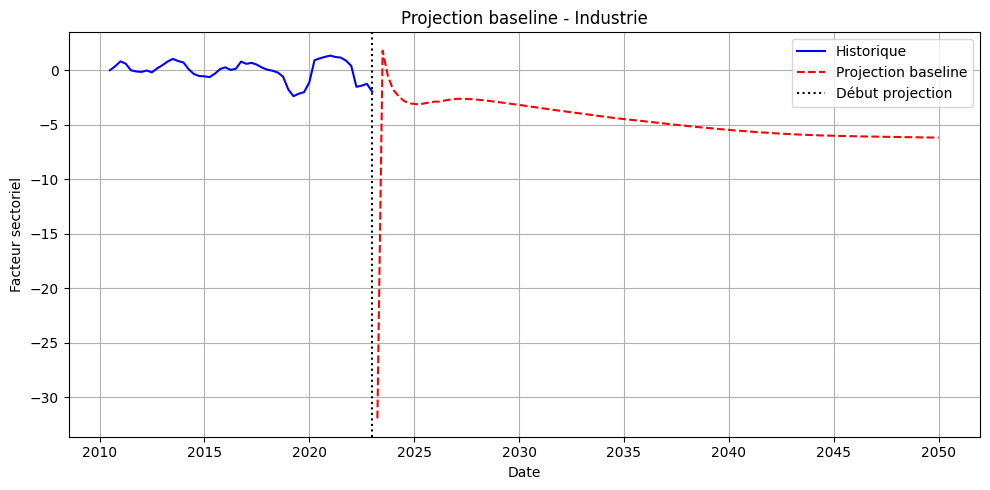

In [92]:
import matplotlib.pyplot as plt

sector_to_plot = "Industrie"  # adapte si besoin

# concat historique + projection
Z_full = pd.concat([Z_hist[sector_to_plot], Z_proj[sector_to_plot]])

plt.figure(figsize=(10,5))

# Historique
plt.plot(Z_hist.index,
         Z_hist[sector_to_plot],
         label="Historique",
         color="blue")

# Projection
plt.plot(Z_proj.index,
         Z_proj[sector_to_plot],
         label="Projection baseline",
         linestyle="--",
         color="red")

plt.axvline(Z_hist.index[-1], color="black", linestyle=":", label="Début projection")

plt.title(f"Projection baseline - {sector_to_plot}")
plt.xlabel("Date")
plt.ylabel("Facteur sectoriel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [85]:
print(Z_hist.index[-1])
print(X_scenario.index[0])

2023-01-01 00:00:00
2022-01-01
